# Supermarket Sales Analysis — Final Project Notebook

**AICTE | IBM SkillsBuild Data Analytics with AI Internship 2026 | BharatCares**  
**AI-Powered Data Analytics Masterclass Series — Capstone Project**  
Prepared by **Aman Kumawat**  
**Dataset:** `SUPER MARKET DATA.xlsx`

This notebook provides a complete, reproducible analysis of the supplied supermarket transaction dataset. It covers data-quality validation, exploratory analysis, business observations, evidence-based hypotheses, and practical recommendations.

> **Execution note:** Keep `SUPER MARKET DATA.xlsx` in the same folder/session as this notebook when running it locally or in Google Colab.


## Project Scope and Business Questions

### Objective
Convert the supplied supermarket transaction data into clear, evidence-based business insights that can support decisions about products, branches, categories, payments, customers, and customer satisfaction.

### Questions addressed
1. How does revenue vary across the complete months in the dataset?
2. Which products and categories contribute most to sales?
3. How do the four branches compare in total sales?
4. How evenly are the four payment methods used?
5. How do Member and Normal transactions differ in volume, revenue, and average transaction value?
6. How do customer ratings vary by category, and is rating linearly associated with transaction sales value?
7. What limitations prevent stronger causal or customer-level conclusions?


## Part 1 — Load the Dataset

In [1]:
# Imports and plotting setup
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

# Consistent colours used across the seven charts
NAVY = "#203864"
TEAL = "#2A9D8F"
GOLD = "#E9A83B"
RED = "#C1666B"
PALETTE = [NAVY, TEAL, GOLD, RED]

# Locate the dataset supplied for this project.
# The submission dataset uses the filename "SUPER MARKET DATA.xlsx".
DATA_CANDIDATES = [
    Path("SUPER MARKET DATA.xlsx"),
    Path("SUPER_MARKET_DATA.xlsx"),  # backward-compatible alternative
]
DATA_FILE = next((p for p in DATA_CANDIDATES if p.exists()), None)

if DATA_FILE is None:
    raise FileNotFoundError(
        "Dataset not found. Upload 'SUPER MARKET DATA.xlsx' to the same "
        "Google Colab/Jupyter session as this notebook."
    )

# Load the dataset
df = pd.read_excel(DATA_FILE, sheet_name=0)

# Parse dates explicitly
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

print(df.head())
print("\nRows, Columns:", df.shape)
print("\nColumn names:", list(df.columns))
print("\nData types:")
print(df.dtypes)


  Invoice ID       Date Branch    City  ... Unit Price      Payment Rating   Sales
0    INV0001 2026-06-01      A  Jaipur  ...      57.13          UPI    3.8  228.52
1    INV0002 2026-02-26      A  Jaipur  ...      66.85  Net Banking    3.9  601.65
2    INV0003 2026-02-09      C  Mumbai  ...      57.28         Card    3.4  171.84
3    INV0004 2026-01-12      C  Mumbai  ...     168.27         Card    4.5  336.54
4    INV0005 2026-06-30      A  Jaipur  ...     130.57         Cash    3.1  652.85

[5 rows x 13 columns]

Rows, Columns: (500, 13)

Column names: ['Invoice ID', 'Date', 'Branch', 'City', 'Customer Type', 'Gender', 'Product', 'Category', 'Quantity', 'Unit Price', 'Payment', 'Rating', 'Sales']

Data types:
Invoice ID               object
Date             datetime64[ns]
Branch                   object
City                     object
Customer Type            object
Gender                   object
Product                  object
Category                 object
Quantity              

## Part 2 — Check Data Quality
Before trusting any chart, confirm the data itself is clean: no missing values, no duplicate transactions, and the `Sales` column actually equals `Quantity × Unit Price`.

In [2]:
# Required columns for this analysis
required_columns = [
    "Invoice ID", "Date", "Branch", "City", "Customer Type", "Gender",
    "Product", "Category", "Quantity", "Unit Price", "Payment", "Rating", "Sales"
]
missing_columns = [c for c in required_columns if c not in df.columns]
if missing_columns:
    raise ValueError(f"Required columns missing from dataset: {missing_columns}")

print("Missing values per column:")
print(df[required_columns].isna().sum())

print("\nDuplicate Invoice IDs:", df["Invoice ID"].duplicated().sum())

# Confirm Sales = Quantity × Unit Price to 2 decimal places
calculated_sales = (df["Quantity"] * df["Unit Price"]).round(2)
mismatches = (calculated_sales - df["Sales"].round(2)).abs().gt(0.01).sum()
print("Rows where Sales does not equal Quantity × Unit Price (after rounding to 2 decimals):", mismatches)

print("Invalid dates:", df["Date"].isna().sum())
print("\nDate range:", df["Date"].min(), "to", df["Date"].max())

print("\nInvalid Quantity (<= 0):", (df["Quantity"] <= 0).sum())
print("Invalid Unit Price (< 0):", (df["Unit Price"] < 0).sum())
print("Invalid Sales (< 0):", (df["Sales"] < 0).sum())
print("Ratings outside 0–5:", (~df["Rating"].between(0, 5)).sum())

df["Month"] = df["Date"].dt.to_period("M")
monthly_counts = df.groupby("Month").size().sort_index()

last_day_by_month = df.groupby("Month")["Date"].max()
month_end_by_month = pd.Series(
    monthly_counts.index.to_timestamp(how="end").date,
    index=monthly_counts.index,
)
partial_months = monthly_counts.index[
    last_day_by_month.dt.date < month_end_by_month
]

print("\nTransactions per month:")
print(monthly_counts)
print("\nPartial month(s) excluded from month-to-month comparison:",
      [str(m) for m in partial_months])


Missing values per column:
Invoice ID       0
Date             0
Branch           0
City             0
Customer Type    0
Gender           0
Product          0
Category         0
Quantity         0
Unit Price       0
Payment          0
Rating           0
Sales            0
dtype: int64

Duplicate Invoice IDs: 0
Rows where Sales does not equal Quantity × Unit Price (after rounding to 2 decimals): 0
Invalid dates: 0

Date range: 2026-01-01 00:00:00 to 2026-07-01 00:00:00

Invalid Quantity (<= 0): 0
Invalid Unit Price (< 0): 0
Invalid Sales (< 0): 0
Ratings outside 0–5: 0

Transactions per month:
Month
2026-01    88
2026-02    65
2026-03    83
2026-04    90
2026-05    85
2026-06    82
2026-07     7
Freq: M, dtype: int64

Partial month(s) excluded from month-to-month comparison: ['2026-07']


**Observation:** The dataset contains 500 rows and 13 columns, with no missing values or duplicate Invoice IDs. `Sales` matches `Quantity × Unit Price` to 2 decimal places for every row. The date coverage ends on 1 July 2026; July contains only 7 transactions and is therefore treated as a partial month and excluded from the monthly comparison.

### Dataset profile

The supplied workbook contains **500 transactions and 13 columns**. The analysis uses the transaction-level fields exactly as provided. July 2026 is treated as a partial month because the dataset contains only seven transactions dated 1 July, so it is excluded from month-to-month revenue comparisons.


### Data Dictionary

| Field | Meaning / analytical role |
|---|---|
| Invoice ID | Unique transaction identifier |
| Date | Transaction date |
| Branch | Branch code (A–D) |
| City | Branch location |
| Customer Type | Member or Normal |
| Gender | Customer gender recorded in the source data |
| Product | Individual product name |
| Category | Product category |
| Quantity | Units purchased in the transaction |
| Unit Price | Price per unit |
| Payment | Payment method used |
| Rating | Customer rating on a 0–5 scale |
| Sales | Transaction sales value; validated against `Quantity × Unit Price` |

**Important scope note:** The dataset has no customer ID, cost/margin, discount, inventory, promotion, staffing, or footfall fields. These missing dimensions limit causal and customer-lifetime conclusions.


## Part 3 — Visualization 1: Monthly Revenue Trend

Month
2026-01    43415.53
2026-02    30068.15
2026-03    37306.42
2026-04    52569.77
2026-05    42542.31
2026-06    35041.46
Freq: M, Name: Sales, dtype: float64

Highest complete month: 2026-04 -> 52569.77
Lowest complete month: 2026-02 -> 30068.15


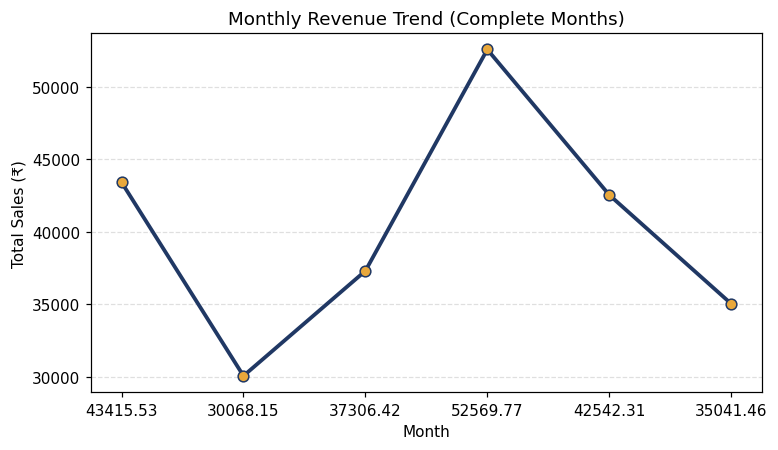

In [3]:
# Group revenue by month, excluding any month that is not fully covered
complete_months = monthly_counts.index.difference(partial_months)
monthly = (
    df[df["Month"].isin(complete_months)]
    .groupby("Month")["Sales"]
    .sum()
    .sort_index()
)

print(monthly)
print("\nHighest complete month:", monthly.idxmax(), "->", round(monthly.max(), 2))
print("Lowest complete month:", monthly.idxmin(), "->", round(monthly.min(), 2))

plt.figure(figsize=(7.2, 4.2), dpi=110)
plt.plot(
    monthly.astype(str),
    monthly.values,
    marker="o",
    color=NAVY,
    linewidth=2.5,
    markersize=7,
    markerfacecolor=GOLD,
    markeredgecolor=NAVY,
)
plt.title("Monthly Revenue Trend (Complete Months)")
plt.xlabel("Month")
plt.ylabel("Total Sales (₹)")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


**Observation:** Among the six complete months, revenue peaked in **April 2026 (₹52,569.77)** and was lowest in **February 2026 (₹30,068.15)**. This is month-to-month variation in the available period; a longer time series would be needed to establish a recurring seasonal pattern.

## Part 4 — Visualization 2: Top Products

Product
Cheese         27906.30
Coffee         27694.87
Shampoo        27497.48
Cooking Oil    21525.06
Tea            17681.59
Apples         17057.41
Face Wash      11946.85
Rice           11754.17
Cold Drink     10731.78
Eggs           10429.77
Name: Sales, dtype: float64

Lowest-selling product: Biscuits -> 3908.87


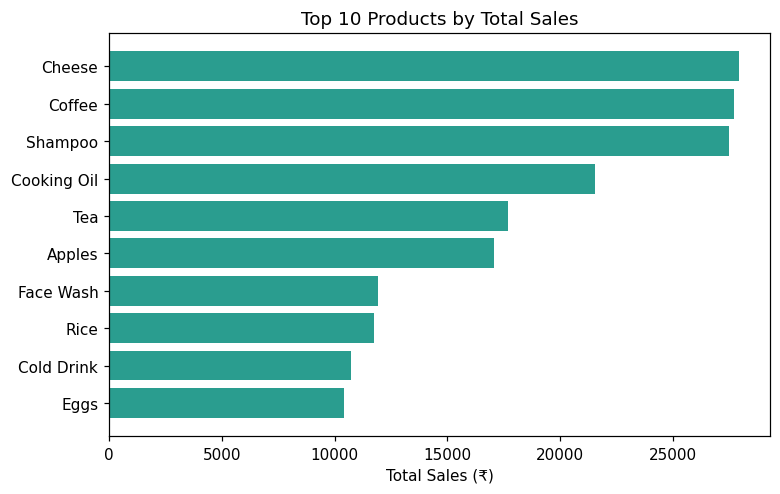

In [4]:
# Total sales by product, highest first
product_sales = df.groupby("Product")["Sales"].sum().sort_values(ascending=False)
print(product_sales.head(10))
print("\nLowest-selling product:", product_sales.idxmin(), "->", round(product_sales.min(), 2))

top10 = product_sales.sort_values(ascending=True).tail(10)
plt.figure(figsize=(7.2, 4.6), dpi=110)
plt.barh(top10.index, top10.values, color=TEAL)
plt.title("Top 10 Products by Total Sales")
plt.xlabel("Total Sales (₹)")
plt.tight_layout()
plt.show()


**Observation:** **Cheese** is the top-selling product (₹27,906.30), closely followed by **Coffee** (₹27,694.87) and **Shampoo** (₹27,497.48) — the top three are within 1.5% of each other. **Biscuits** is the lowest of the 20 products (₹3,908.87).

## Part 5 — Visualization 3: Branch Performance

Branch  City     
C       Mumbai       72469.45
B       Delhi        64116.26
D       Bengaluru    55468.29
A       Jaipur       52357.08
Name: Sales, dtype: float64


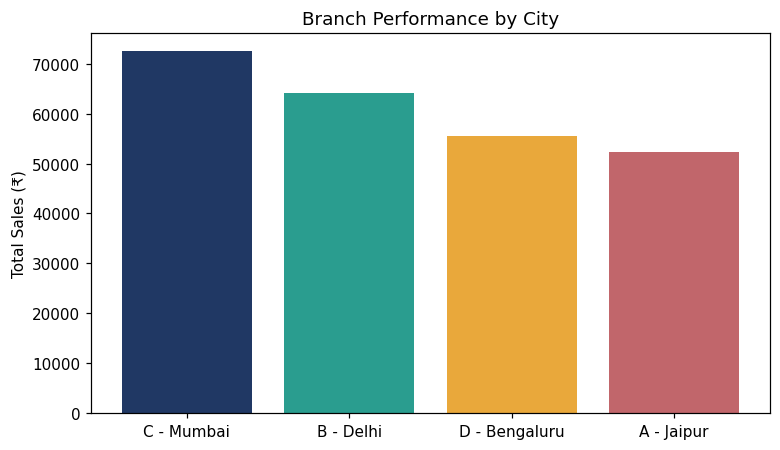

In [5]:
# Total sales by branch and city
branch_sales = df.groupby(["Branch", "City"])["Sales"].sum().sort_values(ascending=False)
print(branch_sales)

labels = [f"{b} - {c}" for b, c in branch_sales.index]
plt.figure(figsize=(7.2, 4.2), dpi=110)
plt.bar(labels, branch_sales.values, color=[NAVY, TEAL, GOLD, RED])
plt.title("Branch Performance by City")
plt.ylabel("Total Sales (₹)")
plt.tight_layout()
plt.show()


**Observation:** **Branch C in Mumbai** generated the highest sales (₹72,469.45); **Branch A in Jaipur** generated the lowest (₹52,357.08) — a ≈ 1.4× spread across the four branches.

## Part 6 — Visualization 4: Category Performance

Category
Beverages        56108.24
Personal Care    45943.96
Dairy            43992.00
Grocery          40470.47
Fruits           23263.17
Snacks           16992.97
Vegetables       11124.17
Bakery            6516.10
Name: Sales, dtype: float64

Share of total revenue (%):
Category
Beverages        23.0
Personal Care    18.8
Dairy            18.0
Grocery          16.6
Fruits            9.5
Snacks            7.0
Vegetables        4.6
Bakery            2.7
Name: Sales, dtype: float64

Top 3 category revenue share: 59.8%


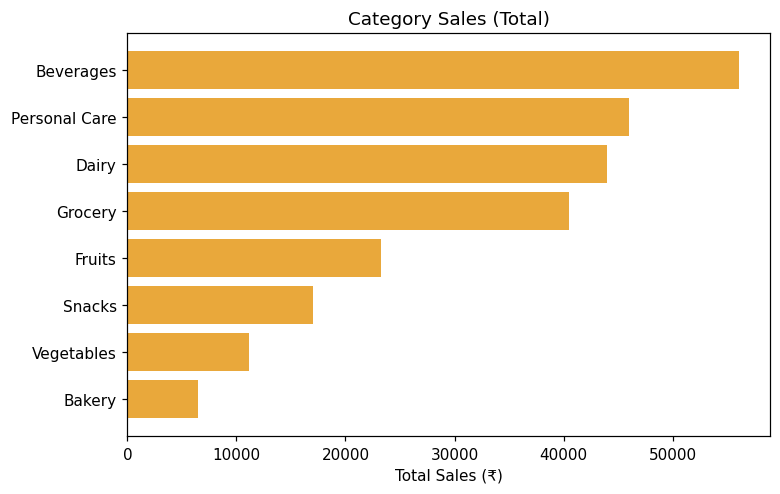

In [6]:
# Total sales by category, highest first
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
print(category_sales)

share = (category_sales / category_sales.sum() * 100).round(1)
print("\nShare of total revenue (%):")
print(share)

top3_share = category_sales.head(3).sum() / category_sales.sum() * 100
print(f"\nTop 3 category revenue share: {top3_share:.1f}%")

ordered = category_sales.sort_values()
plt.figure(figsize=(7.2, 4.6), dpi=110)
plt.barh(ordered.index, ordered.values, color=GOLD)
plt.title("Category Sales (Total)")
plt.xlabel("Total Sales (₹)")
plt.tight_layout()
plt.show()


**Observation:** **Beverages** is the top category (₹56,108.24, ≈ 23% of total revenue); **Bakery** is the lowest (₹6,516.10, ≈ 2.7%) — an ≈ 8.6× gap, the widest disparity found in the dataset.

## Part 7 — Visualization 5: Payment Method Distribution

Payment
UPI            127
Net Banking    126
Card           125
Cash           122
Name: count, dtype: int64

Share of transactions (%):
Payment
UPI            25.4
Net Banking    25.2
Card           25.0
Cash           24.4
Name: count, dtype: float64


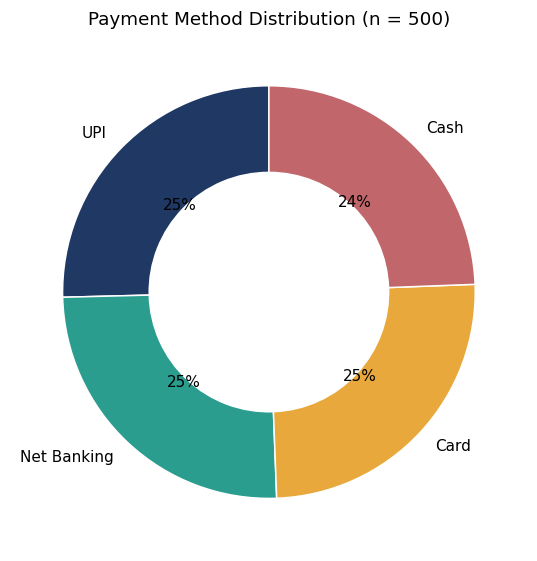

In [7]:
# Count of transactions by payment method
payment_counts = df["Payment"].value_counts()
print(payment_counts)

print("\nShare of transactions (%):")
print((payment_counts / len(df) * 100).round(1))

plt.figure(figsize=(6.6, 5.2), dpi=110)
plt.pie(
    payment_counts.values,
    labels=payment_counts.index,
    colors=PALETTE[:4],
    autopct="%1.0f%%",
    startangle=90,
    wedgeprops=dict(width=0.42, edgecolor="white"),
)
plt.title(f"Payment Method Distribution (n = {len(df)})")
plt.tight_layout()
plt.show()


**Observation:** The four payment methods are used almost equally — **UPI (127), Net Banking (126), Card (125), Cash (122)** — all within 5 transactions of each other out of 500. No single method dominates.

## Part 8 — Visualization 6: Member vs. Normal Customers

               Transactions  Avg_Transaction  Total_Revenue  Avg_Rating
Customer Type                                                          
Member                  296           483.14      143009.30        4.01
Normal                  204           497.07      101401.78        3.97


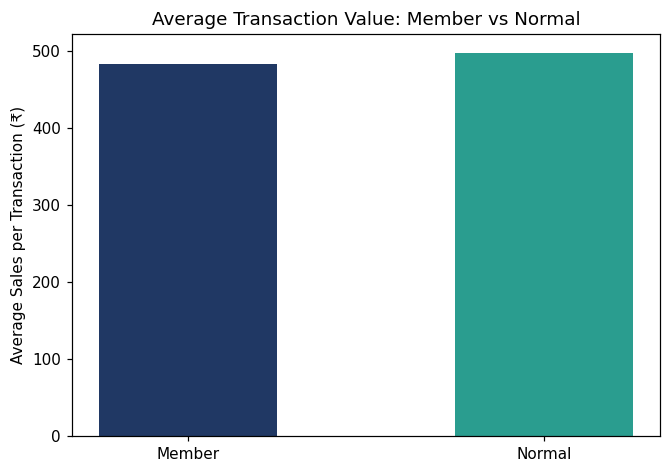

In [8]:
# Compare Member vs Normal customers
customer_summary = df.groupby("Customer Type").agg(
    Transactions=("Sales", "count"),
    Avg_Transaction=("Sales", "mean"),
    Total_Revenue=("Sales", "sum"),
    Avg_Rating=("Rating", "mean"),
).round(2)

print(customer_summary)

plt.figure(figsize=(6.2, 4.4), dpi=110)
plt.bar(
    customer_summary.index,
    customer_summary["Avg_Transaction"],
    color=[NAVY, TEAL],
    width=0.5,
)
plt.title("Average Transaction Value: Member vs Normal")
plt.ylabel("Average Sales per Transaction (₹)")
plt.tight_layout()
plt.show()


**Observation:** Members placed more orders (296 vs. 204) and generated more total revenue (₹143,009.30 vs. ₹101,401.78), but their average transaction value was slightly *lower* (₹483.14) than Normal customers' (₹497.07).

## Part 9 — Visualization 7: Customer Ratings by Category

Overall average rating: 3.99

Average rating by category:
Category
Bakery           4.24
Snacks           4.11
Dairy            4.03
Vegetables       3.99
Beverages        3.96
Personal Care    3.95
Grocery          3.94
Fruits           3.83
Name: Rating, dtype: float64

Pearson correlation between Rating and Sales: -0.047


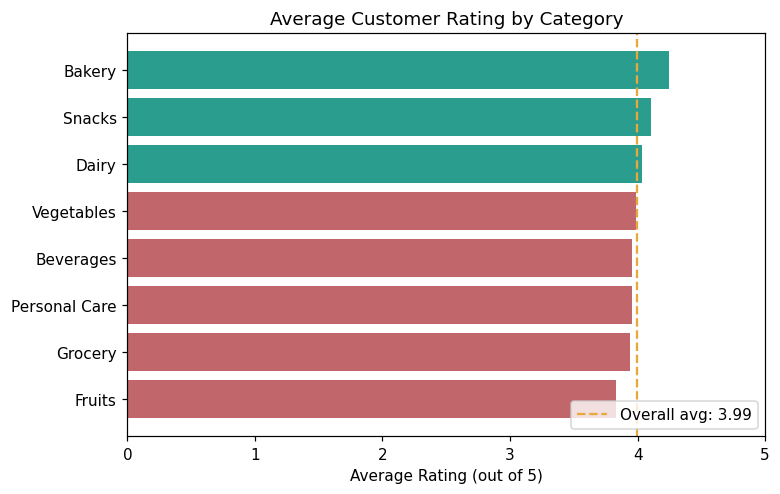

In [9]:
# Average rating overall and by category
overall_rating = df["Rating"].mean()
print("Overall average rating:", round(overall_rating, 2))

rating_by_category = df.groupby("Category")["Rating"].mean().sort_values(ascending=False)
print("\nAverage rating by category:")
print(rating_by_category.round(2))

# Transaction-level Pearson correlation between rating and sales value
correlation = df[["Rating", "Sales"]].corr().iloc[0, 1]
print("\nPearson correlation between Rating and Sales:", round(correlation, 3))

plt.figure(figsize=(7.2, 4.6), dpi=110)
rb = rating_by_category.sort_values()
bar_colors = [RED if v < overall_rating else TEAL for v in rb.values]
plt.barh(rb.index, rb.values, color=bar_colors)
plt.axvline(
    overall_rating,
    color=GOLD,
    linestyle="--",
    label=f"Overall avg: {overall_rating:.2f}",
)
plt.title("Average Customer Rating by Category")
plt.xlabel("Average Rating (out of 5)")
plt.xlim(0, 5)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


**Observation:** The overall average rating is **3.99 / 5**. **Bakery** is rated highest (4.24) despite being the lowest-revenue category, while **Fruits** is rated lowest (3.83). The transaction-level Pearson correlation between rating and sales value is **−0.047**, indicating little linear association in this dataset; this does not by itself prove that the variables are independent or that one does not affect the other.

---
## Part 10 — Insights, Hypotheses & Recommendations

The full reasoning behind these sections lives in the project report (`AmanKumawat_SupermarketSalesAnalysis_ProjectReport.docx`).

**Key Insights**
1. The complete months show meaningful month-to-month variation; April is highest and February is lowest. More historical data would be needed to establish a recurring seasonal pattern.
2. Product revenue is diversified; category revenue is concentrated (Beverages ≈ 23%, top 3 categories ≈ 60%).
3. Branch sales differ across the four branches, with Mumbai highest and Jaipur lowest; the gap is worth investigating.
4. Payment behaviour shows no dominant channel (all four within a 5-transaction band).
5. The Member customer type accounts for more transactions and total revenue in this dataset, while its average transaction value is slightly lower than Normal customers.
6. Ratings and transaction sales value have little linear association in this dataset (Pearson correlation ≈ −0.05); this is not evidence of causation or independence.

**Hypotheses** *(tentative — "may", "might", "could", never stated as fact)*
1. Beverages' lead **might** reflect repeat-purchase frequency or a wider assortment; Bakery's low share **could** reflect fewer SKUs, shelf-life limits, or lower footfall.
2. Branch C's edge **may** relate to location or footfall; Branch A's low revenue and rating **could** share a cause, or be two unrelated issues.
3. Because rating and sales have little linear association, customers **may** be rating service or store experience rather than product value; this would require direct feedback to test.

**Recommendations**
1. Maintain adequate availability for Beverages and pilot an assortment/placement change in Bakery; measure the change before and after the pilot.
2. Compare operational practices across branches and collect direct feedback at Jaipur before attributing the revenue gap to a specific cause.
3. Track sales and ratings as separate KPIs and investigate combinations of strong/weak performance.
4. Maintain availability of all four payment methods; the transaction counts are close enough that the dataset does not support prioritising one method.


## Responsible AI Use and Verification

AI was used as a supporting tool for brainstorming analytical questions, structuring the report, and refining hypothesis wording. It was **not treated as the source of truth for numerical results**.

All reported figures were calculated from the supplied dataset with Python and cross-checked before inclusion. Where the data could not establish causation—such as why one branch or category performs differently—the report explicitly labels the explanation as a hypothesis and identifies what additional evidence would be needed to test it.

This approach keeps the project reproducible, transparent, and evidence-based while demonstrating an appropriate AI-assisted analytics workflow.


---
### Submission Package

The Google Form requests four files:

- **Code:** `AmanKumawat_SupermarketSalesAnalysis.ipynb`
- **Requirements:** `requirements.txt`
- **Project Report:** `AmanKumawat_SupermarketSalesAnalysis_ProjectReport.docx`
- **README:** `README.md`

The notebook uses the supplied dataset **`SUPER MARKET DATA.xlsx`**. Keep that dataset available in the same folder/session when running the notebook.

**Dataset note:** The submitted workbook is the Excel export supplied for this project. No Google Sheets URL is hard-coded because the original URL is not embedded in the workbook or the supplied project files.
